In [ ]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 9)[0]]
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]

def make_converter(params: Params):
    return HarmonyLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        pop_count=20,
        generations=200,
        **params.converter_args)

Min: -0.0127 | Max: 0.0895 | Mean: 0.0426 | Std: 0.0305
Min: -0.0067 | Max: 0.0899 | Mean: 0.0516 | Std: 0.0297
Min: 0.0046 | Max: 0.1187 | Mean: 0.0754 | Std: 0.0360
Min: 0.0411 | Max: 0.1562 | Mean: 0.0991 | Std: 0.0386
Min: 0.0471 | Max: 0.1854 | Mean: 0.1058 | Std: 0.0408


C:\Users\wojte\AppData\Local\Temp\ipykernel_17656\2130949569.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


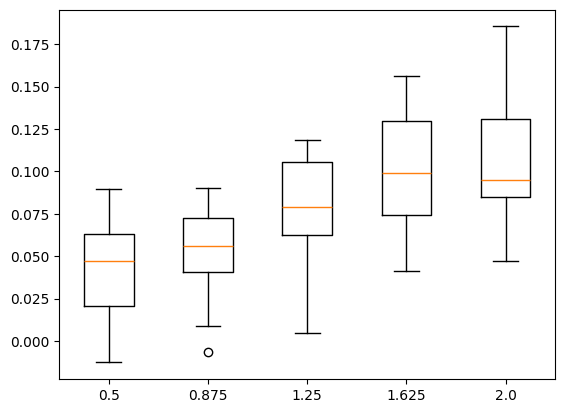

In [ ]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [3]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = HarmonyLineSearch(symbols=SYMBOLS,
                                    font=FONT,
                                    pop_count=20,
                                    generations=200)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    font_height_px = FONT_SIZE * 1.333
    font_width_px = FONT_SIZE * 0.5
    scale_h = MAX_HEIGHT * font_height_px / img.height
    scale_w = MAX_WIDTH * font_width_px / img.width
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    results.append(converter.process_image(img))

print_gallery(results, 2)

---------------------------------------------------------------------
 | /NENDNEDNNNNNENNNNNEEEDDEDyE/E | yDNEDDNENDEyNNNNLDNDNNNyNNyNND | 
 | LyLyLyyLDyEy`E```-/-L`-^-^`^-` | NEDNyEEDNNNDNNDDNDNENDNNENDN/E | 
 | NNDL/DENNDDNNNNyEDDNNNNNDEDNyE | -L/NDENNNNENLD-LDEDDEL/^ENEEEy | 
 | DyNNELNDNNNNNNDNDEDDNDyDNDENL/ | yyDNENNNDE/NN^^-^`EyNNNNEENyED | 
 | ENENDNEND`L/EDDNNDDEENDNDNDDNN | NENDDNyNNDNy/`---^NNDDDDDNNNDD | 
 | NENNDNNyEyNyNDNDEDENNNyDNDEDy^ | DDDNEEENNNyNE-`L`/NNENENLEyEEL | 
 | DDNDNNNNNEEDNLyENNNDDDNNEDDNNy | DDDNDEDNENNNE-/`/`LDENNDDDDNyE | 
 | NEDNENNDNEENDDDNEDEEyDNNDNDNEE | DDDENyNNNNDDEL`^-yNNDDNDDENDDy | 
 | EDDDNDNNDEDNDNNNEENyEDDNNENND^ | DDEDNDNNNNENE/y/ENE^`/EyENENNL | 
---------------------------------------------------------------------
 | NNNNNNDDE//DyEDELNNDy/ENDNDN/y | ```````-```-```` | 
 | EyEDDDEEyDDEyDNEEEED^E`^y```LL | ``-```/E`L`L`L`- | 
 | EDLDENDEEDEDEDDEyyyyEEEEyEyLyL | ENNNDNNNNNNENEND | 
 | `D/NDNDENEENNNNNEENNNDNNENNNNE | ENNNENENDNNNENEN | 
 | yN^